### Import relavant packages

In [24]:
import numpy as np
from astropy.io import fits
from matplotlib import pyplot as plt
import camb
from astropy.cosmology import Planck18
from iminuit import Minuit

### Import emulator

In [2]:
from lace.archive import gadget_archive
from lace.emulator.gp_emulator_new import GPEmulator

### Retrain the emulator: not needed (check?)

In [3]:
mpg_arch_C23 = gadget_archive.GadgetArchive(postproc="Pedersen21")

In [4]:
nn_emu_C23 = GPEmulator(archive=mpg_arch_C23,train=True,save=True)

Select emulator in CH24_mpg_gp
Storing emulator in /Users/anoma_1/LaCE/data/GPmodels/CH24_mpg_gp


 /opt/anaconda3/envs/cup1d/lib/python3.11/site-packages/paramz/parameterized.py:61: RuntimeWarning:Don't forget to initialize by self.initialize_parameter()!


GPs optimised in 0.57 seconds


### Input parameters of the emulator

In [5]:
nn_emu_C23.emu_params

['Delta2_p', 'n_p', 'mF', 'sigT_Mpc', 'gamma', 'kF_Mpc']

#### Linear matter power spectrum from CAMB

In [6]:
def getCambLinearPowerInterp(zlist, omch2=0.11934063901639999, ombh2=0.0224178568132, H0=67.66):
    camb_params = camb.set_params(
        redshifts=sorted(zlist, reverse=True),
        WantCls=False, WantScalars=False,
        WantTensors=False, WantVectors=False,
        WantDerivedParameters=False,
        WantTransfer=True,
        omch2=omch2,
        ombh2=ombh2,
        omk=0.,
        H0=H0,
        ns=0.965,
        As=np.exp(3.044) * 1e-10,
        # mnu=0.
    )
    camb_results = camb.get_results(camb_params)

    # Note this interpolator in Mpc units without h
    camb_interp = camb_results.get_matter_power_interpolator(
        nonlinear=False, hubble_units=False,
        k_hunit=False, extrap_kmax=5.)
    
    return camb_interp.P

In [7]:
plin_interp = getCambLinearPowerInterp([3.6, 3.2, 2.8, 2.2])

### Amplitude and spectral index of the linear matter power spectrum from CAMB

In [8]:
def getDeltapNp(z, plin_interp, kpivot=0.7):
    Deltap = kpivot**3 * plin_interp(z, kpivot) / (2 * np.pi**2)
    logkp = np.log(kpivot)
    dlogk = 0.01 * logkp
    k = np.exp(logkp + np.array([-2., -1., 1., 2.]) * dlogk)
    weights = np.array([1., -8., 8., -1.]) / (12 * dlogk)

    logP = np.log(plin_interp(z, k))

    Np = logP.dot(weights)
    
    return Deltap, Np

In [9]:
Deltap, Np = getDeltapNp(3.2, plin_interp)
print(Deltap, Np)

0.3166177635051896 -2.30877063414664


### Ly-alpha mean flux models

In [ ]:
def turner24_mf(z):
    return np.exp(-2.46e-3 * (1 + z)**3.62)

def meanFluxBecker(z, tau0=0.751, beta=2.90, C=-0.132, z0=3.5):
    x0 = (1 + z) / (1 + z0)

    tau_eff = C + tau0 * np.power(x0, beta)

    return np.exp(-tau_eff) 

### Emulator input model

In [27]:
def getModelDict(z):
    Deltap, Np = getDeltapNp(z, plin_interp)
    model = {
        'Delta2_p': Deltap, 'n_p': Np,
        'mF': meanFluxBecker(z), 'sigT_Mpc': 0.12,
        'gamma': 1.5, 'kF_Mpc': 12.
    }
    return model

### 1D Ly-alpha power spectrum predicted by the emulator

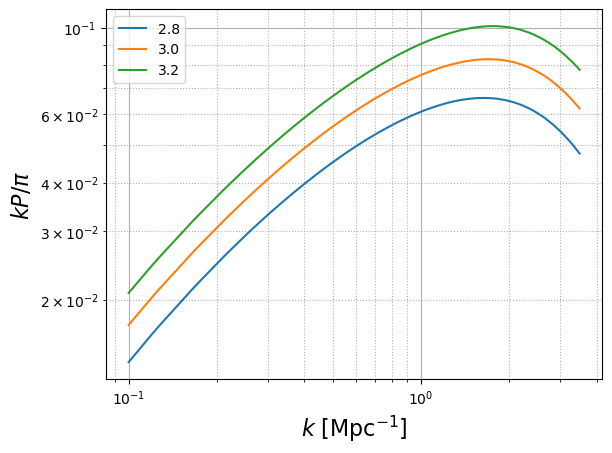

In [12]:
kMpc = np.linspace(0.1, 3.5, 1000)
kskm = kMpc / 100.

for z in [2.8, 3.0, 3.2]:
    model = getModelDict(z)
    emu_p1d = nn_emu_C23.emulate_p1d_Mpc(model, kMpc)[0]
    plt.plot(kMpc, kMpc * emu_p1d / np.pi, label=z)
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.xlabel(r"$k$ [Mpc$^{-1}$]", fontsize=16)
plt.ylabel(r"$k P / \pi$", fontsize=16)
plt.grid()
plt.grid(True, "minor", ls=':')

## $\chi^2$ evaluation

#### Data and Covariance matrix

In [13]:
p1d_obs = fits.open('../../../data_points/desi_y1_snr3_p1d_sb1subt_qmle_power_estimate_contcorr_v3.fits')
print("---P1D Observation FITS File Info ---")
p1d_obs.info()

---P1D Observation FITS File Info ---
Filename: ../../../data_points/desi_y1_snr3_p1d_sb1subt_qmle_power_estimate_contcorr_v3.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  P1D_BLIND     1 BinTableHDU     52   1020R x 14C   [D, D, D, D, D, D, D, D, D, D, D, D, D, D]   
  2  SYSTEMATICS    1 BinTableHDU     29   1020R x 10C   [D, D, D, D, D, D, D, D, D, D]   
  3  COVARIANCE    1 ImageHDU         9   (1020, 1020)   float64   
  4  COVARIANCE_STAT    1 ImageHDU         9   (1020, 1020)   float64   
  5  COVARIANCE_SYST    1 ImageHDU         9   (1020, 1020)   float64   


In [14]:
p1d_obs['P1D_BLIND'].data

FITS_rec([(2.2, 0.        , 0.0005    , 0.00025   , 18.41146 , 22.96678001, 33.49281938, 4.85764804, 42.96773 ,  5.48822 , 14.523808 , 2.56809868, 4.1233013 , 36.60381454),
          (2.2, 0.0005    , 0.001     , 0.00075   , 22.73209 ,  1.99230026, 20.47006331, 1.09132457, 20.972393,  0.075566, 18.904088 , 0.39634566, 1.01680845, 26.38631131),
          (2.2, 0.001     , 0.0015    , 0.00125   , 22.55656 ,  2.24579023, 21.7766764 , 0.52979984, 22.881667,  0.615834, 20.020145 , 0.30222758, 0.43513947, 24.13087492),
          ...,
          (4.4, 0.04978761, 0.05094731, 0.05036746,  9.077918,  0.78069258,  9.72766468, 7.23515829, 19.961097,  8.877156, 10.3032506, 6.09595794, 3.89702609, 18.76853711),
          (4.4, 0.05094731, 0.05213402, 0.05154067,  8.631555,  3.71018995, 12.21496435, 7.45966377, 22.942412,  9.426753,  9.8054709, 6.32348796, 3.95728235, 18.19384588),
          (4.4, 0.05213402, 0.05334838, 0.0527412 ,  8.202126, 13.681305  , 21.7606929 , 7.83451112, 36.800395, 12.19505

In [15]:
LIGHT_SPEED = 299792.458  # km/s
LYA_WAVELENGTH = 1215.67  # Angstroms
desi_dlambda = 0.8  # Angstrom

### Obtaining the power spectrum amplitude evolution using the linear growth function

In [17]:
z_star = 3.0
# kms2hMpc = 100.0 * Planck18.h * Planck18.efunc(z) / (1 + z)  # km/s / Mpc


def getLinearGrowthMasai(z, Om0):
    # https://arxiv.org/abs/1012.2671
    a = 1.0 / (1 + z)
    x = (1 - Om0) / Om0 * a**3

    bs = np.array([0.005355, 0.3064, 1.175, 1.0])
    cs = np.array([0.1530, 1.021, 1.857, 1.0])
    return a * np.sqrt(1 + x) * np.polyval(bs, x) / np.polyval(cs, x)

def delta2p_star2z(delta2p_star, z, Om0):
    pivotD = getLinearGrowthMasai(z_star, Om0)**2
    return delta2p_star * getLinearGrowthMasai(z, Om0)**2 / pivotD

### DESI DR1 measurement used to generate mock P1d:

delta2star_mean= 0.379
\
delta2star_std= 0.032
\
nstar_mean= -2.309
\
nstar_std= 0.019

In [18]:
def scale_cuts(data, cov):
    desi_rkms = (
        LIGHT_SPEED * desi_dlambda
        / (1 + data['Z']) / LYA_WAVELENGTH
    )
    desi_kmax = np.pi / desi_rkms / 2

    w = (data['K'] < desi_kmax) & (data['K'] > 1e-3)
    Cov_cut = cov[np.ix_(w, w)]
    k_cut = data['K'][w]
    z_cut = data['Z'][w]
    p1d_cut = data['PLYA'][w]

    # Organize by redshift bins
    z_bins = np.unique(z_cut)
    z_bin_indices = [np.where(np.isclose(z_cut, z))[0] for z in z_bins]
    k_cut_bins = [k_cut[indices] for indices in z_bin_indices]
    p1d_cut_bins = [p1d_cut[indices] for indices in z_bin_indices]
    return Cov_cut, k_cut_bins, z_bins

def p1d_mock(delta2p_star, np_star):
    _, k_cut_bins, z_bins = scale_cuts(data, cov)
    Om0 = Planck18.Om0
    p1d_emus = []
    for i, zb in enumerate(z_bins):
        Deltap_z = delta2p_star2z(delta2p_star, zb, Om0)
        kms2hMpc = 100.0 * Planck18.h * Planck18.efunc(zb) / (1 + zb)  # km/s / Mpc
        kMpc = k_cut_bins[i] * kms2hMpc
        model = {
            'Delta2_p': Deltap_z, 'n_p': np_star,
            'mF': turner24_mf(zb), 'sigT_Mpc': 0.12,
            'gamma': 1.5, 'kF_Mpc': 12.
        }
        emu_p1d = nn_emu_C23.emulate_p1d_Mpc(model, kMpc)
        p1d_emus.append(emu_p1d * kms2hMpc)

    p1d_model = np.hstack(p1d_emus)[0]
    return p1d_model

In [22]:
data = p1d_obs['P1D_BLIND'].data
cov = p1d_obs['COVARIANCE'].data
p1d_cut = p1d_mock(0.379, -2.309)

def get1sigma_error(data, cov):
    Cov_cut, k_cut_bins, z_bins = scale_cuts(data, cov)
    Cov_cut_inv = np.linalg.solve(Cov_cut, np.eye(Cov_cut.shape[0]))
    Om0 = Planck18.Om0
    def chi2(delta2p_star, np_star):
        p1d_emus = []
        for i, zb in enumerate(z_bins):
            Deltap_z = delta2p_star2z(delta2p_star, zb, Om0)
            kms2hMpc = 100.0 * Planck18.h * Planck18.efunc(zb) / (1 + zb)  # km/s / Mpc
            kMpc = k_cut_bins[i] * kms2hMpc
            model = {
                'Delta2_p': Deltap_z, 'n_p': np_star,
                'mF': turner24_mf(zb), 'sigT_Mpc': 0.12,
                'gamma': 1.5, 'kF_Mpc': 12.
            }
            emu_p1d = nn_emu_C23.emulate_p1d_Mpc(model, kMpc)
            p1d_emus.append(emu_p1d * kms2hMpc)

        p1d_model = np.hstack(p1d_emus)[0]
        diff = p1d_model - p1d_cut
        return diff.dot(Cov_cut_inv).dot(diff)

    lambda_chi2 = lambda delta2p_star, np_star: chi2(delta2p_star, np_star)
    m = Minuit(lambda_chi2, delta2p_star=0.379, np_star=-2.309)
    m.migrad()
    return m.errors['delta2p_star'], m.errors['np_star']

 /Users/anoma_1/LaCE/lace/emulator/gp_emulator_new.py:455: UserWarning:Some of the requested k's are lower than the minimum training value k=0.09308422677303091


#### 1-$\sigma$ error on amplitude and spectral index

In [25]:
get1sigma_error(data, cov)

(0.0025905234975552023, 0.003334318803613922)